In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler,RobustScaler,OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report)
from sklearn import metrics

In [ ]:
df_original = pd.read_csv('../datasets/processed/heart_no_nans.csv')
df_original.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,No,No,Yes,No,...,"White only, Non-Hispanic",Age 80 or older,1.60,78.02,30.47,No,No,No,No,No
1,Alabama,Female,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,Yes,Yes,No,...,"White only, Non-Hispanic",Age 80 or older,1.45,59.87,28.56,No,No,Yes,Yes,No
2,Alabama,Female,Very good,2.0,0.0,Within past 5 years (2 years but less than 5 y...,Yes,No,No,No,...,"White only, Non-Hispanic",Age 75 to 79,1.68,77.11,27.44,No,Yes,Yes,Yes,No
3,Alabama,Female,Fair,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,No,Yes,No,...,"White only, Non-Hispanic",Age 75 to 79,1.73,77.11,25.85,Yes,No,No,Yes,No
4,Alabama,Female,Good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,Yes,Yes,No,...,"Black only, Non-Hispanic",Age 60 to 64,1.57,74.84,30.18,Yes,Yes,No,No,Yes


In [3]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257697 entries, 0 to 257696
Data columns (total 37 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      257697 non-null  object 
 1   Sex                        257697 non-null  object 
 2   GeneralHealth              257697 non-null  object 
 3   PhysicalHealthDays         257697 non-null  float64
 4   MentalHealthDays           257697 non-null  float64
 5   LastCheckupTime            257697 non-null  object 
 6   PhysicalActivities         257697 non-null  object 
 7   HighCholesterol            257697 non-null  object 
 8   HighBloodPressure          257697 non-null  object 
 9   HadHeartAttack             257697 non-null  object 
 10  HadAngina                  257697 non-null  object 
 11  HadStroke                  257697 non-null  object 
 12  HadAsthma                  257697 non-null  object 
 13  HadSkinCancer              25

In [4]:
for col in df_original.columns:
    print(f"{col}: {df_original[col].unique()}")

State: ['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Louisiana' 'Maine'
 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota' 'Mississippi'
 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire' 'New Jersey'
 'New Mexico' 'New York' 'North Carolina' 'North Dakota' 'Ohio' 'Oklahoma'
 'Oregon' 'Rhode Island' 'South Carolina' 'South Dakota' 'Tennessee'
 'Texas' 'Utah' 'Vermont' 'Virginia' 'Washington' 'West Virginia'
 'Wisconsin' 'Wyoming' 'Guam' 'Puerto Rico' 'Virgin Islands']
Sex: ['Female' 'Male']
GeneralHealth: ['Very good' 'Fair' 'Good' 'Excellent' 'Poor']
PhysicalHealthDays: [ 0.  2.  1.  5.  4. 15. 30. 21. 10. 25. 14.  7. 20.  3. 12. 26.  8. 24.
 18. 13.  6. 28. 17. 11. 16. 22. 27.  9. 29. 23. 19.]
MentalHealthDays: [ 0.  3. 25. 10.  2. 20. 30. 15.  5. 12.  4.  1.  6. 21.  7. 14. 29.  8.
 16. 17.  9. 28. 11. 18. 22. 24. 13. 27. 26. 19. 23.]

In [5]:
numerical_df = df_original.select_dtypes(include=['number'])
numerical_df

,PhysicalHealthDays,MentalHealthDays,HeightInMeters,WeightInKilograms,BMI
0,0.0,0.0,1.60,78.02,30.47
1,0.0,0.0,1.45,59.87,28.56
2,2.0,0.0,1.68,77.11,27.44
3,0.0,0.0,1.73,77.11,25.85
4,2.0,3.0,1.57,74.84,30.18
...,...,...,...,...,...
257692,0.0,0.0,1.68,73.94,26.31
257693,0.0,0.0,1.75,66.22,21.56
257694,0.0,0.0,1.65,68.04,24.96
257695,10.0,0.0,1.68,96.62,34.38


In [7]:
df = df_original.copy()

In [8]:
df['PhysicalHealthDays'] = df['PhysicalHealthDays'].apply(int)
df['MentalHealthDays'] = df['MentalHealthDays'].apply(int)
numerical_df2 = df.select_dtypes(include=['number'])
numerical_df2

,PhysicalHealthDays,MentalHealthDays,HeightInMeters,WeightInKilograms,BMI
0,0,0,1.60,78.02,30.47
1,0,0,1.45,59.87,28.56
2,2,0,1.68,77.11,27.44
3,0,0,1.73,77.11,25.85
4,2,3,1.57,74.84,30.18
...,...,...,...,...,...
257692,0,0,1.68,73.94,26.31
257693,0,0,1.75,66.22,21.56
257694,0,0,1.65,68.04,24.96
257695,10,0,1.68,96.62,34.38


In [9]:
#label encoder

label_encoder = LabelEncoder()

label_columns = ['Sex']

for col in label_columns:
    df[col] = label_encoder.fit_transform(df[col])

df = pd.get_dummies(df, columns=['RaceEthnicityCategory'], drop_first=True)

#ordinal mapping
ordinal_mapping = {
    'GeneralHealth': { "Excellent": 5, "Very good": 4, "Good": 3, "Fair": 2, "Poor": 1 },
    'SmokerStatus': { "Current smoker - now smokes every day": 4,
                     "Current smoker - now smokes some days": 3,
                     "Former smoker": 2,
                     "Never smoked": 1 },
    'ECigaretteUsage': { "Never used e-cigarettes in my entire life": 1,
                         "Use them every day": 4,
                         "Use them some days": 3,
                         "Not at all (right now)": 2 },
    'AgeCategory': { "Age 18 to 24": 1, "Age 25 to 29": 2, "Age 30 to 34": 3,
                    "Age 35 to 39": 4, "Age 40 to 44": 5, "Age 45 to 49": 6,
                    "Age 50 to 54": 7, "Age 55 to 59": 8, "Age 60 to 64": 9,
                    "Age 65 to 69": 10, "Age 70 to 74": 11, "Age 75 to 79": 12,
                    "Age 80 or older": 13 },
    'LastCheckupTime':{'Within past year (anytime less than 12 months ago)': 0,
                    'Within past 2 years (1 year but less than 2 years ago)': 1,
                    'Within past 5 years (2 years but less than 5 years ago)': 2,
                    '5 or more years ago': 3},
    'HadDiabetes':{'No': 0,
                    'No, pre-diabetes or borderline diabetes': 1,
                    'Yes, but only during pregnancy (female)': 2,
                    'Yes': 3},
    'HighBloodPressure':{'No': 0,
                    'No, pre-hypertension or borderline high blood pressure': 1,
                    'Yes, but female told only during pregnancy': 2,
                    'Yes': 3}

}

for col, mapping in ordinal_mapping.items():
    df[col] = df[col].map(mapping)

#Yes No statement
df.replace({'No': 0, 'Yes': 1}, inplace=True)

#state encoding
state_encoding = df.groupby('State')['HadHeartAttack'].mean().to_dict()
df['State'] = df['State'].map(state_encoding)

/var/folders/9t/rxgyh0d12kb5lqq62w0vc0wh0000gn/T/ipykernel_9590/2486560736.py:47: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'No': 0, 'Yes': 1}, inplace=True)


In [10]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
0,0.061382,0,4,0,0,1,0,0,3,0,...,30.47,0,0,0,0,0,False,False,False,True
1,0.061382,0,4,0,0,1,1,1,3,0,...,28.56,0,0,1,1,0,False,False,False,True
2,0.061382,0,4,2,0,2,1,0,0,0,...,27.44,0,1,1,1,0,False,False,False,True
3,0.061382,0,2,0,0,0,1,0,3,0,...,25.85,1,0,0,1,0,False,False,False,True
4,0.061382,0,3,2,3,0,1,1,3,0,...,30.18,1,1,0,0,1,False,False,False,False


In [11]:
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Prediksi
y_pred_smote = logreg.predict(X_test_scaled)
y_pred_proba_smote = logreg.predict_proba(X_test_scaled)
y_pred_custom = (y_pred_proba_smote[:, 1] > 0.6).astype(int)

# ROC & AUC
fpr_smote, tpr_smote, _ = metrics.roc_curve(y_test, y_pred_proba_smote[:, 1])
auc_smote = round(metrics.auc(fpr_smote, tpr_smote), 5)

# DataFrame evaluasi SMOTE
smote_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_custom),
    precision_score(y_test, y_pred_custom),
    recall_score(y_test, y_pred_custom),
    f1_score(y_test, y_pred_custom),
    auc_smote
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_SMOTE"])
# Lihat hasil evaluasi
print(smote_eval)

           Logistic_Regression_SMOTE
Accuracy                    0.946100
Precision                   0.588710
Recall                      0.150515
F1-score                    0.239737
AUC                         0.877200


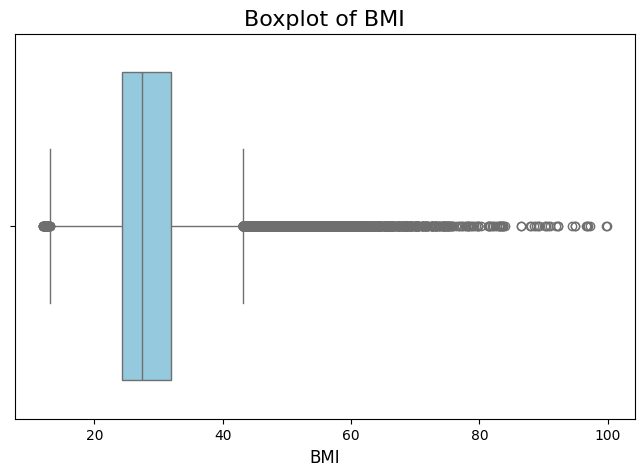

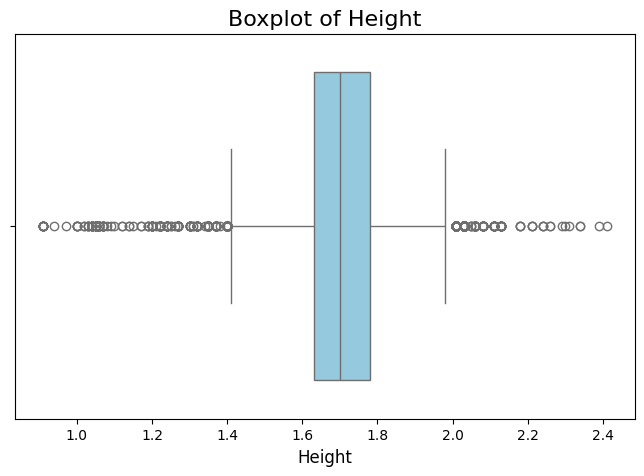

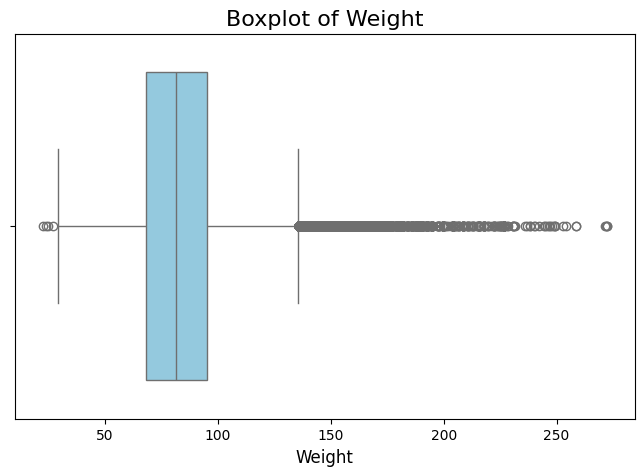

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['BMI'], color='skyblue')
plt.title('Boxplot of BMI', fontsize=16)
plt.xlabel('BMI', fontsize=12)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['HeightInMeters'], color='skyblue')
plt.title('Boxplot of Height', fontsize=16)
plt.xlabel('Height', fontsize=12)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['WeightInKilograms'], color='skyblue')
plt.title('Boxplot of Weight', fontsize=16)
plt.xlabel('Weight', fontsize=12)
plt.show()


In [14]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['BMI'] < lower_bound) | (df['BMI'] > upper_bound)]
outliers.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
25,0.061382,0,3,0,0,0,1,1,3,0,...,44.39,0,0,0,0,1,False,False,False,True
41,0.061382,0,2,5,10,0,0,0,0,0,...,51.65,1,1,1,0,1,False,False,False,True
47,0.061382,0,4,0,0,0,0,0,3,0,...,53.72,0,0,1,0,1,False,False,False,False
108,0.061382,1,2,30,15,0,0,1,3,0,...,46.11,0,0,1,1,0,False,False,False,True
115,0.061382,0,2,14,10,0,1,0,3,0,...,47.43,0,1,1,1,1,False,False,False,False


In [15]:
df_sorted = df.sort_values(by=['HeightInMeters'], ascending=[True])
df_sorted.head(20)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
82341,0.060407,0,1,4,14,0,0,1,3,0,...,75.95,0,1,1,1,0,False,False,False,True
97962,0.054759,1,4,30,0,0,1,0,0,0,...,92.22,1,1,1,0,1,True,False,False,False
204659,0.054825,0,4,0,0,0,1,0,0,0,...,79.75,0,0,0,1,1,False,False,False,True
100403,0.054759,0,3,0,0,0,1,0,0,0,...,54.25,1,0,0,0,0,True,False,False,False
32819,0.042642,0,2,0,0,0,1,0,0,0,...,73.24,1,0,1,1,1,False,False,False,True
43263,0.074898,1,4,0,1,0,1,0,0,0,...,94.94,1,0,0,0,1,False,False,False,True
229613,0.049108,0,3,2,1,0,0,1,0,0,...,43.40,1,0,1,1,0,False,False,False,True
186254,0.056032,0,4,1,1,0,1,0,0,0,...,71.61,1,0,1,0,1,False,False,False,True
173827,0.068999,1,4,1,5,0,0,0,0,0,...,92.22,0,1,0,0,1,False,False,False,True
109551,0.058862,0,3,4,4,0,1,0,3,0,...,96.56,0,0,1,0,1,False,False,False,True


In [16]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print('Before:', df.shape)
df_clean = remove_outliers_iqr(df, 'BMI')
print('After:', df_clean.shape)


Before: (257697, 40)
After: (249550, 40)


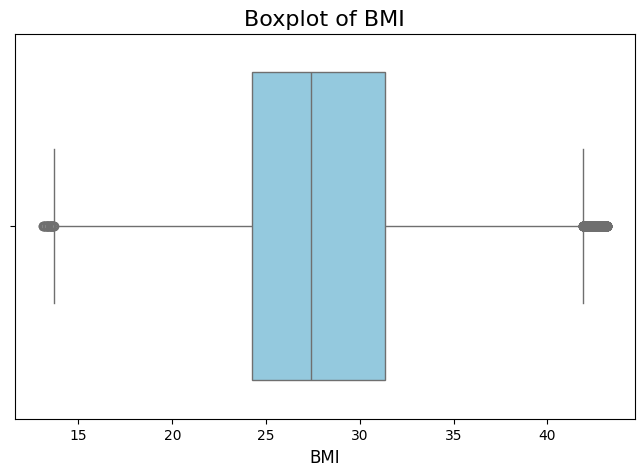

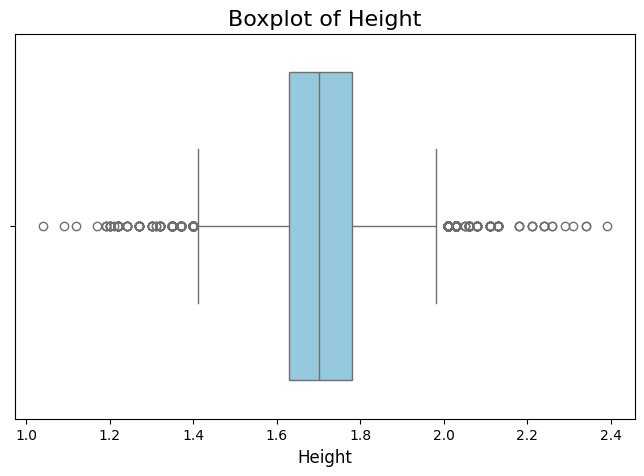

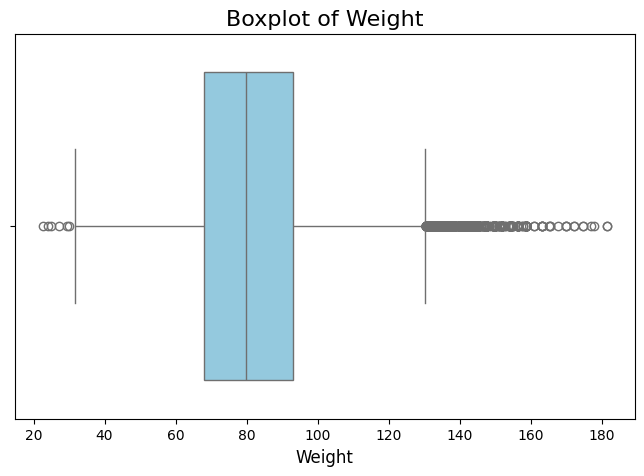

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['BMI'], color='skyblue')
plt.title('Boxplot of BMI', fontsize=16)
plt.xlabel('BMI', fontsize=12)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['HeightInMeters'], color='skyblue')
plt.title('Boxplot of Height', fontsize=16)
plt.xlabel('Height', fontsize=12)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['WeightInKilograms'], color='skyblue')
plt.title('Boxplot of Weight', fontsize=16)
plt.xlabel('Weight', fontsize=12)
plt.show()

In [18]:
# Hitung IQR lagi dari df_clean
Q1 = df_clean['BMI'].quantile(0.25)
Q3 = df_clean['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ambil baris yang outlier BMI di df_clean
outliers = df_clean[(df_clean['BMI'] < lower_bound) | (df_clean['BMI'] > upper_bound)]
outliers.head()


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
62,0.061382,0,3,0,0,0,0,0,3,0,...,42.23,0,0,0,1,1,False,False,False,False
226,0.061382,0,2,8,0,0,1,1,3,0,...,42.51,0,0,1,1,0,False,False,False,False
262,0.061382,0,3,0,0,0,1,1,3,0,...,42.77,0,0,0,0,1,False,False,False,True
294,0.061382,0,2,14,7,0,0,1,3,0,...,41.96,0,1,1,1,0,False,False,False,True
633,0.061382,0,2,0,0,0,0,1,3,0,...,42.40,0,0,1,1,0,False,False,False,False


In [19]:
df_sorted_clean = df_clean.sort_values(by=['BMI'], ascending=[True])
df_sorted_clean.head(20)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
53774,0.048405,0,1,28,0,0,1,0,0,1,...,13.11,0,0,1,0,1,False,False,True,False
9061,0.057793,1,5,0,0,0,1,0,0,0,...,13.13,0,0,1,1,1,False,False,True,False
984,0.061382,0,3,0,0,0,0,0,0,0,...,13.16,0,0,1,1,0,False,False,False,True
204716,0.054825,0,3,0,0,1,1,0,0,0,...,13.22,0,0,0,0,0,True,False,False,False
91257,0.072750,0,3,0,0,0,0,1,3,0,...,13.23,0,0,1,1,1,False,False,False,True
104679,0.046072,0,4,0,0,1,1,1,0,0,...,13.23,0,0,1,0,1,False,False,False,True
111699,0.058862,0,4,0,0,1,1,0,0,0,...,13.31,0,1,0,0,0,False,False,False,False
118660,0.052408,1,3,2,1,0,1,0,0,0,...,13.31,0,0,0,0,1,False,False,False,True
104231,0.046072,0,1,15,7,0,0,0,0,0,...,13.31,0,1,1,0,0,True,False,False,False
240793,0.083852,0,5,0,0,0,0,0,3,0,...,13.31,0,0,0,1,0,False,False,False,True


In [20]:
X = df_clean.drop('HadHeartAttack', axis=1)
y = df_clean['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Prediksi
y_pred_smote = logreg.predict(X_test_scaled)
y_pred_proba_smote = logreg.predict_proba(X_test_scaled)
y_pred_custom = (y_pred_proba_smote[:, 1] > 0.6).astype(int)

# ROC & AUC
fpr_smote, tpr_smote, _ = metrics.roc_curve(y_test, y_pred_proba_smote[:, 1])
auc_smote = round(metrics.auc(fpr_smote, tpr_smote), 5)

# DataFrame evaluasi SMOTE
smote_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_custom),
    precision_score(y_test, y_pred_custom),
    recall_score(y_test, y_pred_custom),
    f1_score(y_test, y_pred_custom),
    auc_smote
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_NoResample"])
# Lihat hasil evaluasi
print(smote_eval)

           Logistic_Regression_NoResample
Accuracy                         0.946524
Precision                        0.604816
Recall                           0.151580
F1-score                         0.242407
AUC                              0.882480


In [22]:
df_clean.to_csv('../datasets/processed/heart_no_outliers.csv', index=False)